<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°10

**Objetivo**: Analizar y modelar series temporales de datos delictivos en Montreal, aplicando métodos estadísticos y de aprendizaje automático para la predicción.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


### Conjunto de datos



<img src="https://svgsilh.com/svg/3350822.svg" width="350"  align="center"/>


El conjunto de datos **`interventionscitoyendo.csv`** proviene del *Service de police de la Ville de Montréal* (SPVM) y contiene el registro de todos los **actos delictivos ocurridos en Montreal entre 2015 y agosto de 2020**.

Cada incidente está clasificado en **categorías generales de delito** e incluye información contextual como la **ubicación geográfica**, la **fecha y hora** del suceso, así como otros atributos relevantes para el análisis.

Este dataset resulta especialmente útil para estudios de **series temporales**, ya que permite agrupar los delitos por intervalos de tiempo (días, semanas, meses) y analizar patrones de comportamiento delictual en la ciudad.

> **Nota**: Puede consultarse más información oficial en el [portal de datos abiertos de Montreal](https://donnees.montreal.ca/ville-de-montreal/actes-criminels).


In [2]:
# librerias

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX


# graficos incrustados
plt.style.use('fivethirtyeight')
%matplotlib inline

# parametros esteticos de seaborn
sns.set_palette("deep", desat=.6)
sns.set_context(rc={"figure.figsize": (12, 4)})

In [3]:
# metrics


def mae(targets, predictions) -> float:
    """
    Calculo de la metrica: mean absolute error (MAE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round(np.abs(error).mean(), 4)


def mse(targets, predictions) -> float:
    """
    Calculo de la metrica: mean squared error (MSE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round((error ** 2).mean(), 4)


def rmse(targets, predictions) -> float:
    """
    Calculo de la metrica: root mean squared error (RMSE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    return round(np.sqrt((error ** 2).mean()), 4)


# b) Percentage errors

def mape(targets, predictions) -> float:
    """
    Calculo de la metrica: mean absolute percentage error (MAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets

    if any(x == 0 for x in targets):
        return np.inf
    else:
        return round(np.abs(error / targets).mean(),4)


def maape(targets, predictions) -> float:
    """
    Calculo de la metrica:  mean arctangent percentage error  (MAAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """

    error = predictions - targets

    if any((x, y) == (0, 0) for x, y in zip(predictions, targets)):
        return np.inf

    else:
        return round(np.arctan(np.abs(error / targets)).mean(),4)


def wmape(targets, predictions) -> float:
    """
    Calculo de la metrica:  weighted mean absolute percentage error (WMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    sum_values = np.sum(targets)

    if sum_values == 0:
        return np.inf
    else:
        return round(np.abs(error).sum() / sum_values,4)


def mmape(targets, predictions) -> float:
    """
    Calculo de la metrica: modified mean absolute percentage error (MMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = np.abs(predictions - targets)
    denom = 1 + np.abs(targets)

    return round(np.mean(error / denom),4)


def smape(targets, predictions) -> float:
    """
    Calculo de la metrica: symmetric mean absolute percentage error (SMAPE)
    :param targets: valor real
    :param predictions: valor estimado
    :return: valor de la metrica
    """
    error = predictions - targets
    sum_values = np.abs(predictions) + np.abs(targets)

    if any(x == 0 for x in sum_values):
        return np.inf

    else:
        return round(2 * np.mean(np.abs(error) / sum_values),4)

def summary_metrics(df) -> pd.DataFrame:
    """
    Aplicar las distintas metricas definidas
    :param df:  dataframe con las columnas: ['y','yhat']
    :return: dataframe con las metricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mae(y_true, y_pred), 4)]
    df_result['mse'] = [round(mse(y_true, y_pred), 4)]
    df_result['rmse'] = [round(rmse(y_true, y_pred), 4)]

    df_result['mape'] = [round(mape(y_true, y_pred), 4)]
    df_result['maape'] = [round(maape(y_true, y_pred), 4)]
    df_result['wmape'] = [round(wmape(y_true, y_pred), 4)]
    df_result['mmape'] = [round(mmape(y_true, y_pred), 4)]
    df_result['smape'] = [round(smape(y_true, y_pred), 4)]

    # nombre del modelo por defecto
    #try:
    #    model = df['model'][0]
    #    df_result['model'] = [model]
    #except:
    #    df_result['model'] = ['---']

    return df_result

In [4]:
# read data

validate_categorie = [
  'Introduction', 'Méfait','Vol dans / sur véhicule à moteur', 'Vol de véhicule à moteur',
]

df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/interventionscitoyendo.csv", sep=",", encoding='latin-1')
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

df = df.loc[lambda x: x['categorie'].isin(validate_categorie)]
df = df.sort_values(['categorie','date'])
df.head()

,categorie,date,quart,pdq,x,y,longitude,latitude
3462,Introduction,2015-01-01,jour,42.0,297210.375006,5.050179e+06,-73.597273,45.591480
8370,Introduction,2015-01-01,soir,13.0,297145.531007,5.032845e+06,-73.597834,45.435501
11968,Introduction,2015-01-01,nuit,8.0,289215.072000,5.036423e+06,-73.699308,45.467564
12763,Introduction,2015-01-01,soir,27.0,293203.472992,5.045436e+06,-73.648516,45.548740
13686,Introduction,2015-01-01,soir,44.0,298915.433995,5.046912e+06,-73.575381,45.562090


Como tenemos muchos datos por categoría a nivel de día, agruparemos a nivel de **semanas** y separaremos cada serie temporal.

In [23]:
cols = ['date','pdq']
y_s1 = df.loc[lambda x: x.categorie == validate_categorie[0] ][cols].set_index('date').resample('W').mean()
y_s2 = df.loc[lambda x: x.categorie == validate_categorie[1] ][cols].set_index('date').resample('W').mean()
y_s3 = df.loc[lambda x: x.categorie == validate_categorie[2] ][cols].set_index('date').resample('W').mean()
y_s4 = df.loc[lambda x: x.categorie == validate_categorie[3] ][cols].set_index('date').resample('W').mean()



El objetivo de este laboratorio es realizar un **análisis integral** del conjunto de datos, aplicando técnicas de visualización y modelado de series temporales. Para ello, se deben abordar las siguientes tareas:

1. **Visualizar las series temporales** \$y\_{si}, ; i=1,2,3,4\$, generando gráficos que permitan identificar patrones, tendencias y estacionalidades.



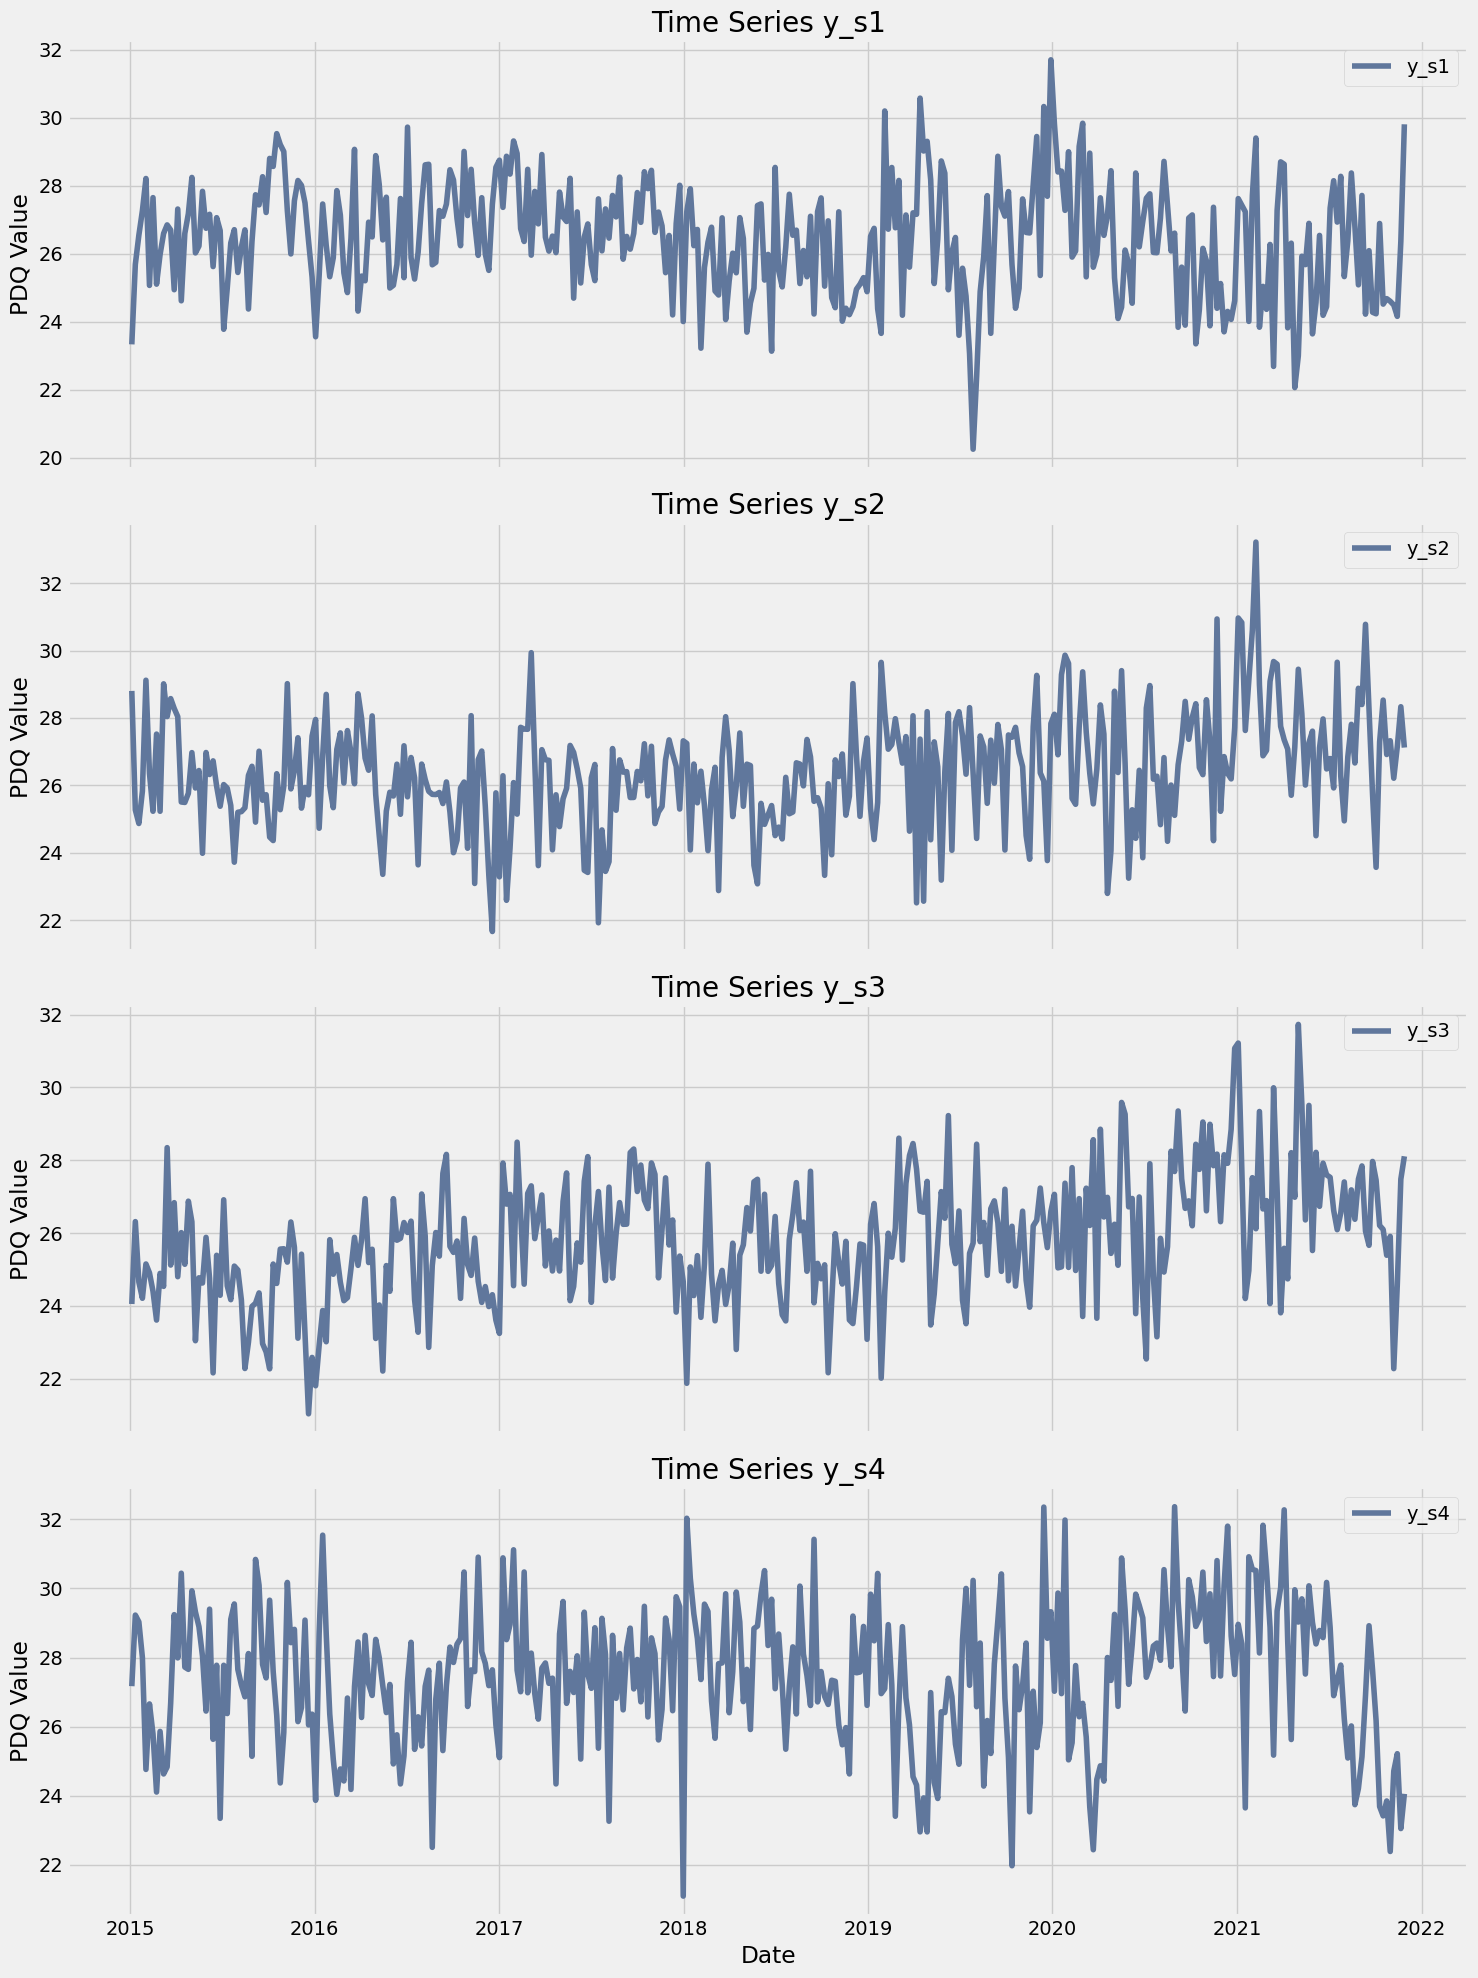

In [6]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 20), sharex=True)

series = {
    'y_s1': y_s1,
    'y_s2': y_s2,
    'y_s3': y_s3,
    'y_s4': y_s4
}

for i, (name, s) in enumerate(series.items()):
    axes[i].plot(s.index, s['pdq'], label=name)
    axes[i].set_title(f'Time Series {name}')
    axes[i].set_ylabel('PDQ Value')
    axes[i].legend()
    axes[i].grid(True)

plt.xlabel('Date')
plt.tight_layout()
plt.show()



1. Seleccione una de las series temporales \$y\_{si}, ; i=1,2,3,4\$ y desarrolle lo siguiente:

* **Análisis exploratorio**: examine la serie elegida identificando patrones, tendencias y posibles estacionalidades.
* **Modelado con SARIMA**: ajuste un modelo \$SARIMA(p,d,q) \times (P,D,Q,S)\$ probando distintas configuraciones de hiperparámetros. Compare resultados, seleccione la mejor configuración y justifique su elección.
* **Validación del modelo**: evalúe los residuos del modelo óptimo y determine si se comportan como **ruido blanco**.

> **Nota**: Utilice como `target_date` = `'2021-01-01'`. Recuerde que la columna de valores se llama `pdq`.



In [22]:
# creando clase SarimaModels

class SarimaModels:
    def __init__(self,params):

        self.params = params


    @property
    def name_model(self):
        return f"SARIMA_{self.params[0]}X{self.params[1]}".replace(' ','')

    @staticmethod
    def test_train_model(y,date):
        mask_ds = y.index < date

        y_train = y[mask_ds]
        y_test = y[~mask_ds]

        return y_train, y_test

    def fit_model(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        model_fit = model.fit(disp=0)

        return model_fit

    def df_testig(self,y,date):
        y_train, y_test = self.test_train_model(y,date )
        model = SARIMAX(y_train,
                        order=self.params[0],
                        seasonal_order=self.params[1],
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        model_fit = model.fit(disp=0)

        start_index = y_test.index.min()
        end_index = y_test.index.max()

        preds = model_fit.get_prediction(start=start_index,end=end_index, dynamic=False)
        df_temp = pd.DataFrame(
            {
                'y':y_test['pdq'],
                'yhat': preds.predicted_mean
            }
        )

        return df_temp

    def metrics(self,y,date):
        df_temp = self.df_testig(y,date)
        df_metrics = summary_metrics(df_temp)
        df_metrics['model'] = self.name_model

        return df_metrics

# definir parametros

import itertools

p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

params = list(itertools.product(pdq,seasonal_pdq))
target_date = '2021-01-01'


--- Exploratory Analysis for y_s4 ---



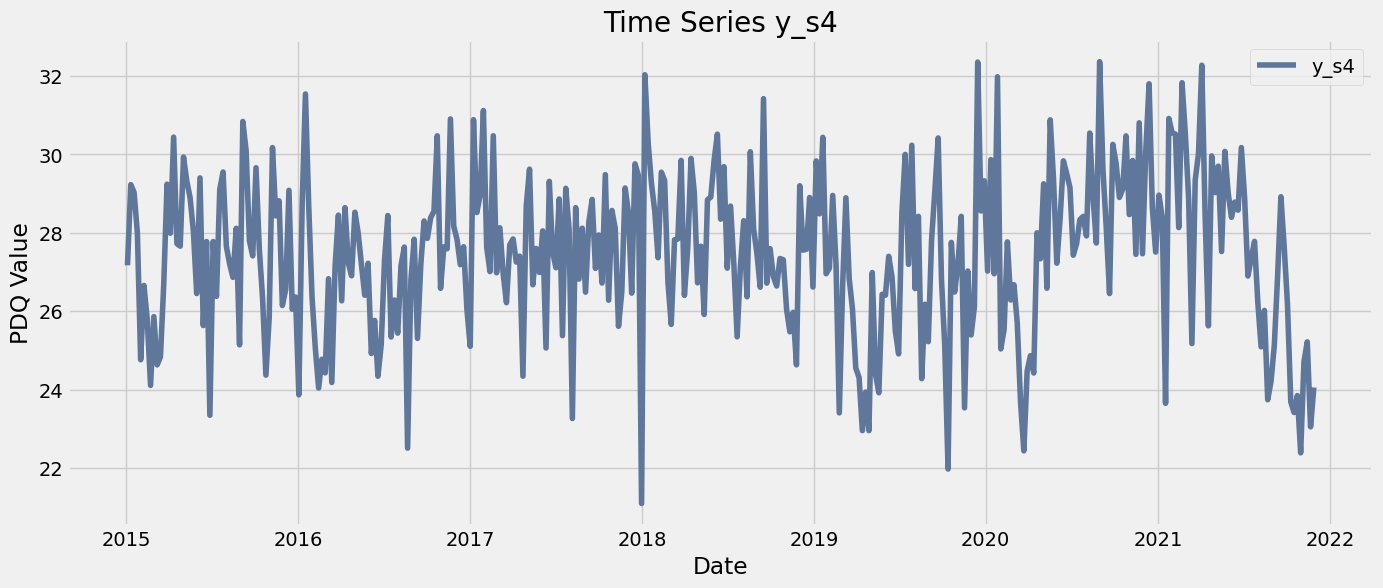

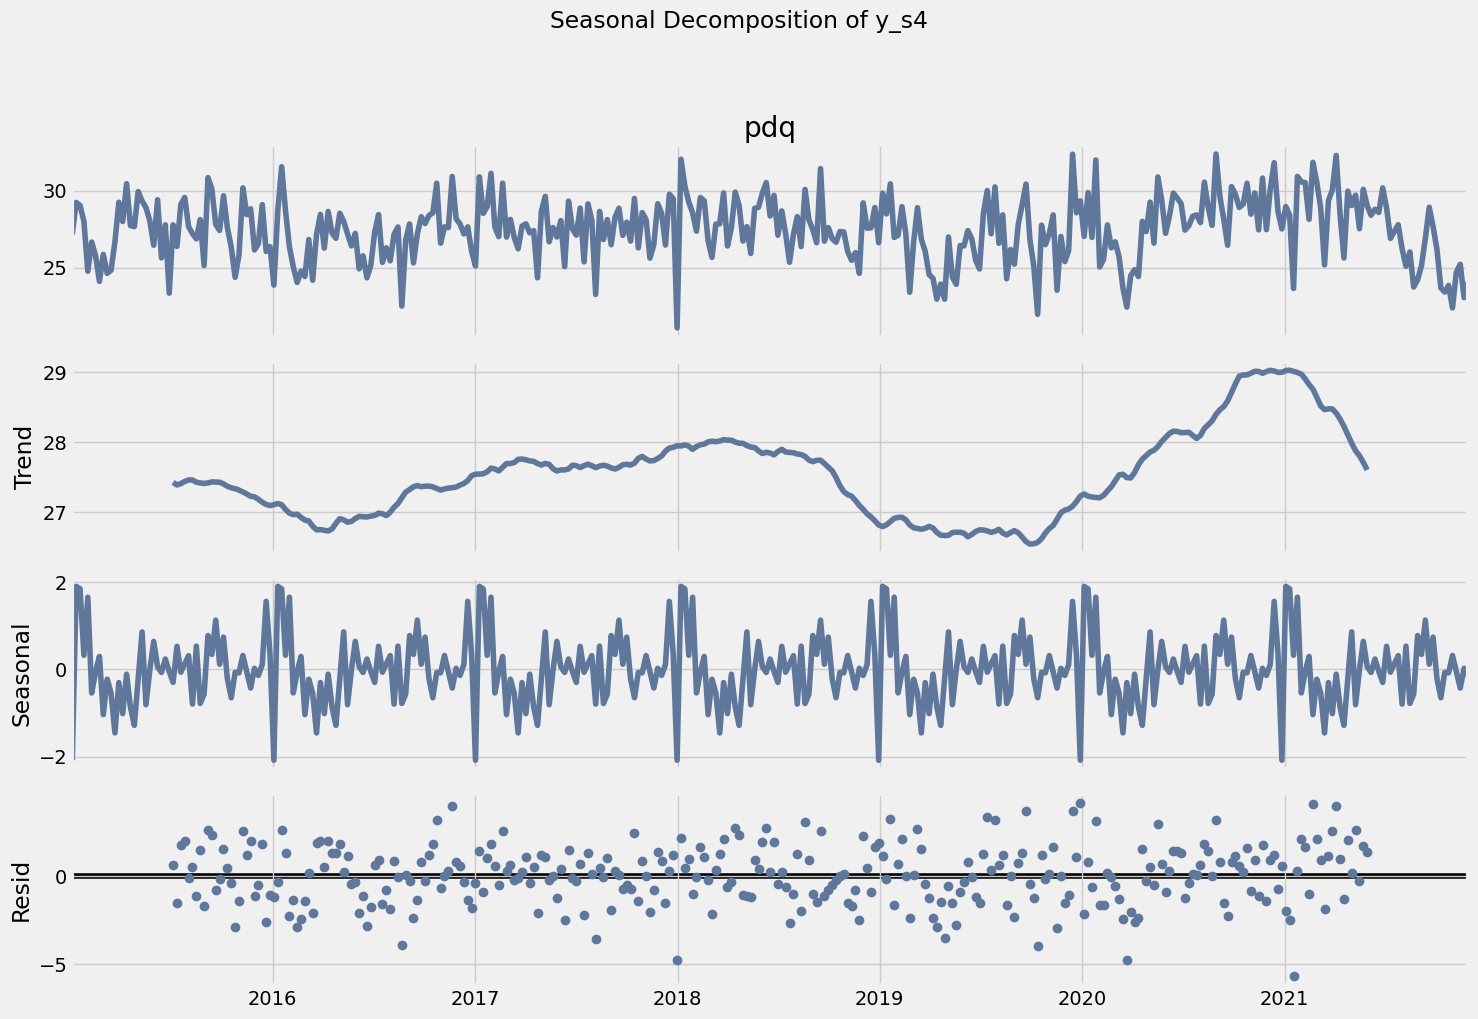

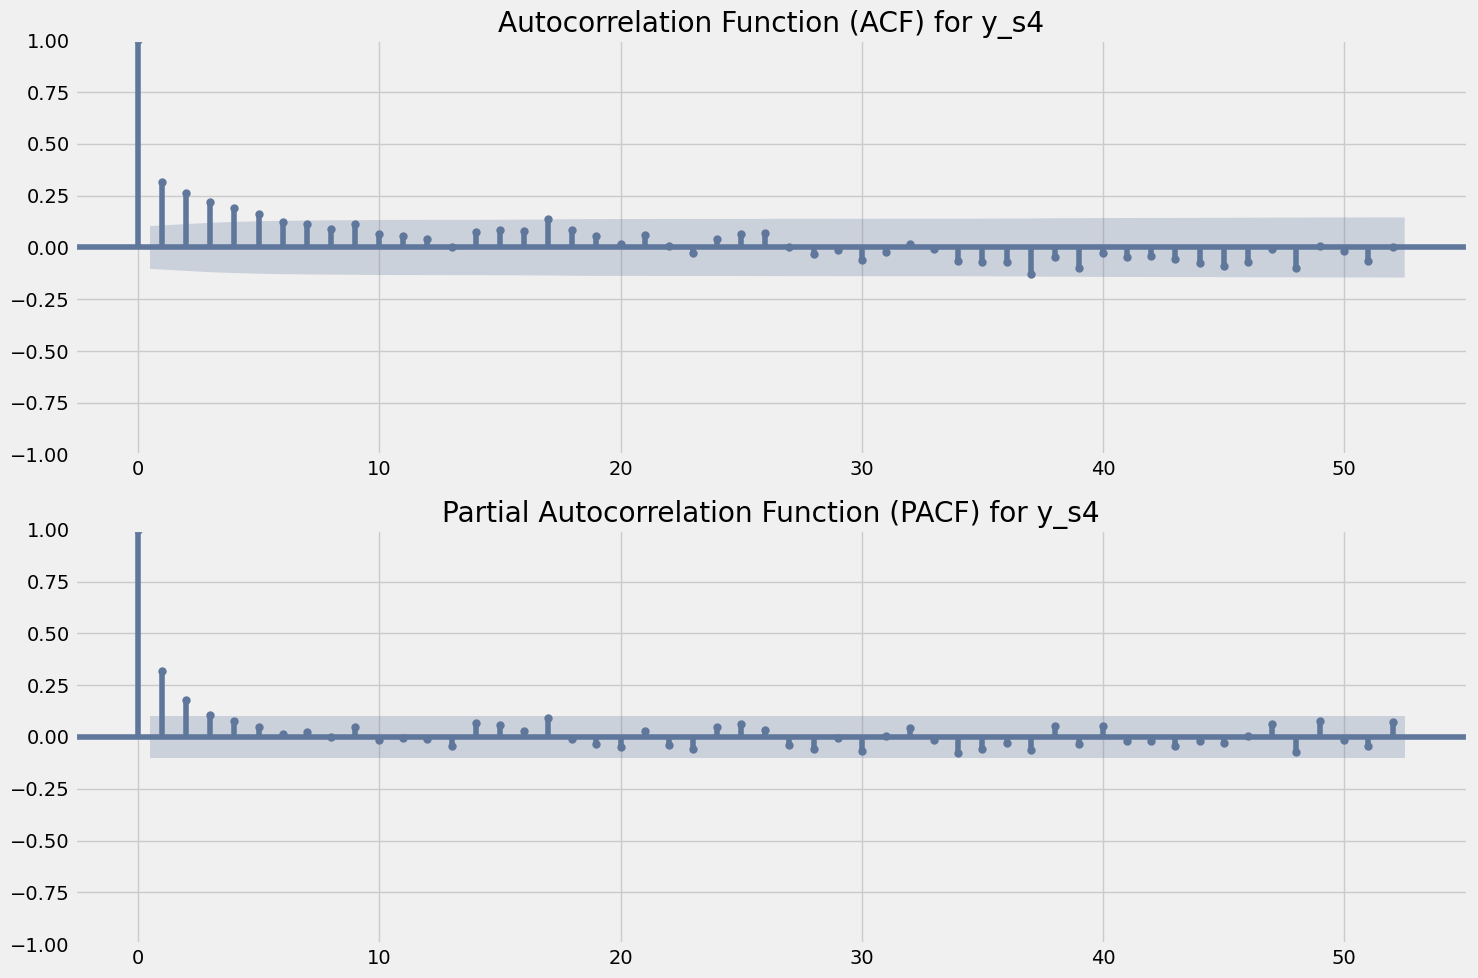


--- SARIMA Model Selection for y_s4 ---

Best SARIMA Model Configuration (based on RMSE on test set):

mae                         2.0806
mse                         5.9165
rmse                        2.4324
mape                        0.0756
maape                       0.0753
wmape                       0.0759
mmape                       0.0729
smape                       0.0764
model    SARIMA_(0,1,0)X(1,1,0,12)
Name: 22, dtype: object

Optimal (p,d,q): (0, 1, 0)
Optimal (P,D,Q,S): (1, 1, 0, 12)

--- Model Validation (Residual Analysis) ---



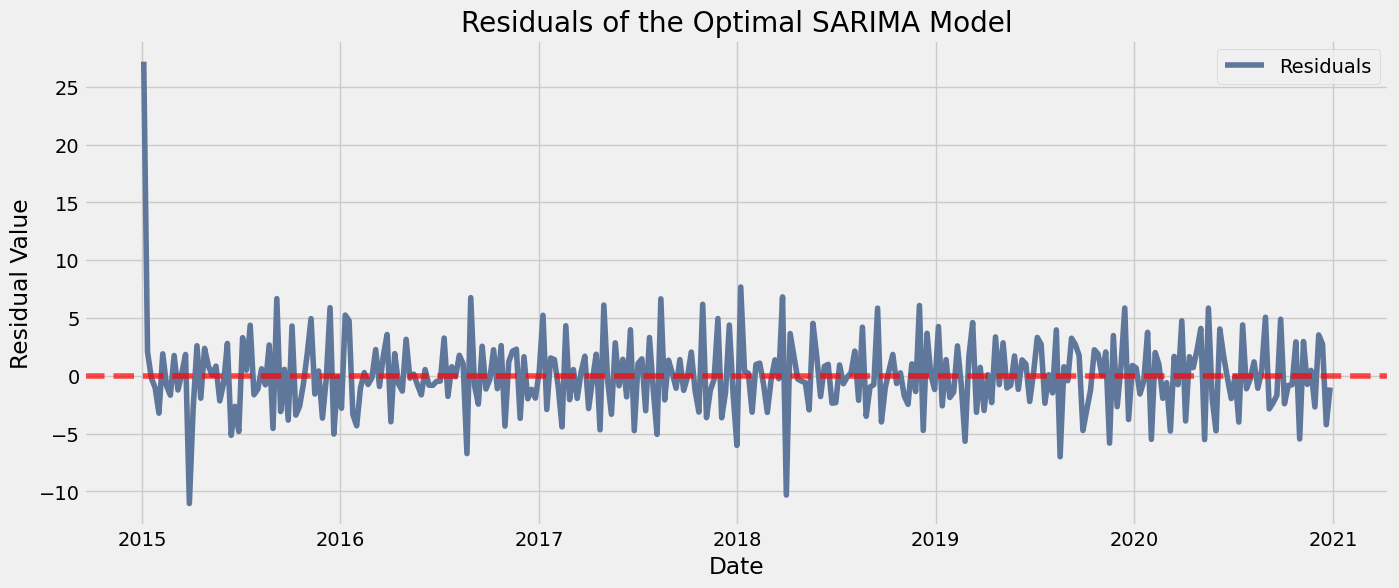

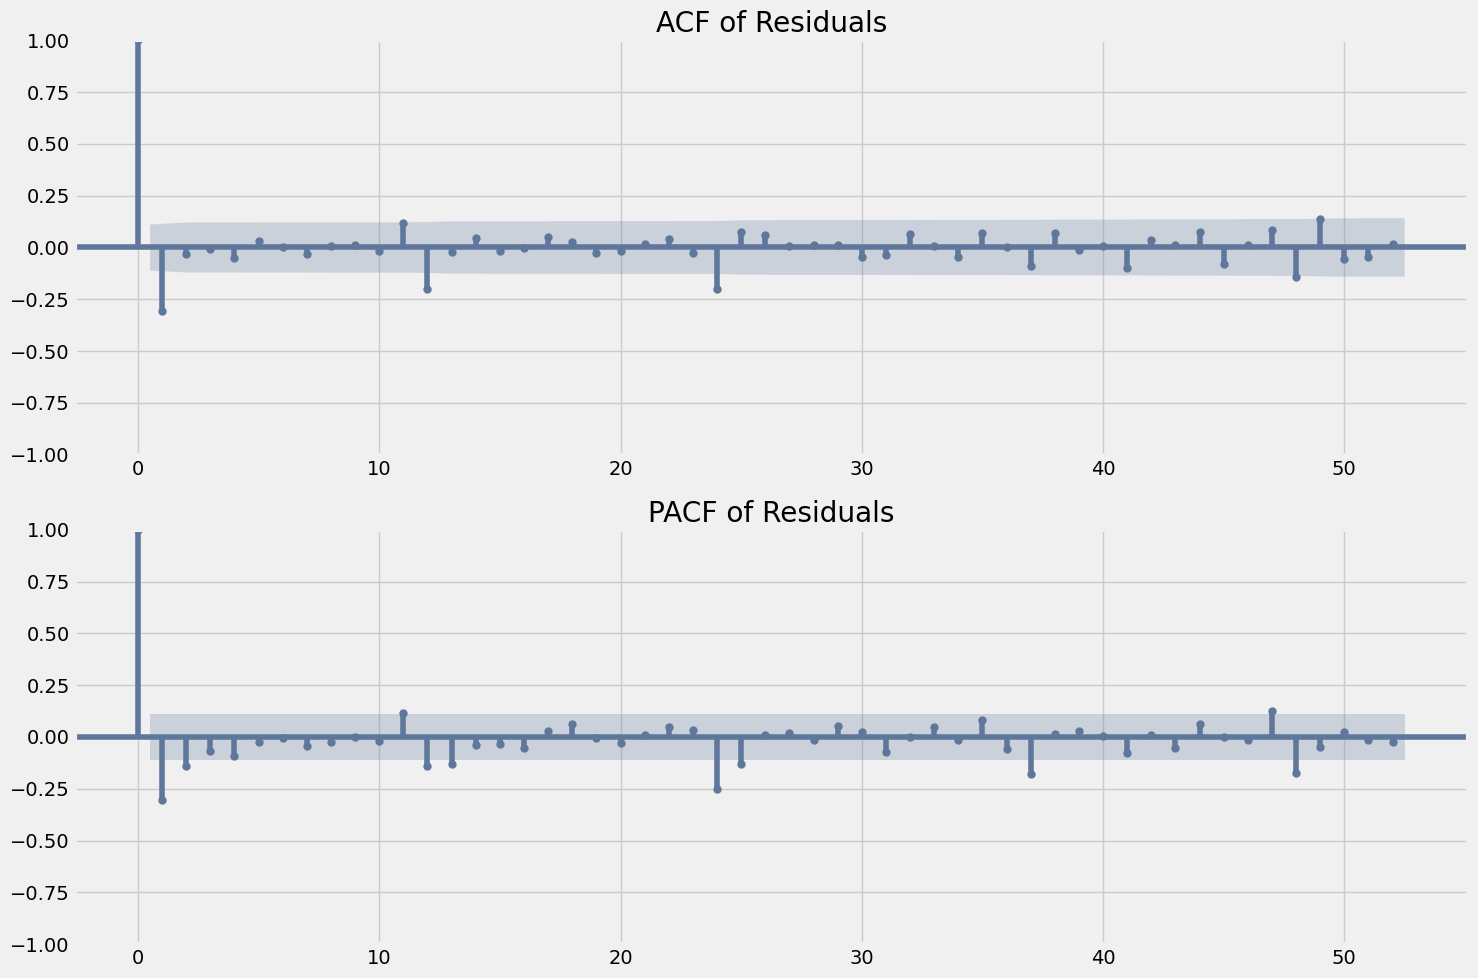


Ljung-Box test for residuals (p-value > 0.05 indicates white noise):

      lb_stat  lb_pvalue
10  31.491427   0.000487
20  51.313446   0.000143
30  69.689485   0.000053


In [21]:
# --- 1. Exploratory Analysis for y_s4 ---

print("\n--- Exploratory Analysis for y_s4 ---\n")

# Plot the time series
plt.figure(figsize=(15, 6))
plt.plot(y_s4.index, y_s4['pdq'], label='y_s4')
plt.title('Time Series y_s4')
plt.xlabel('Date')
plt.ylabel('PDQ Value')
plt.legend()
plt.grid(True)
plt.show()

# Seasonal Decomposition
decomposition = sm.tsa.seasonal_decompose(y_s4['pdq'], model='additive', period=52) # Assuming weekly data, period is 52 weeks
fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.suptitle('Seasonal Decomposition of y_s4', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

# ACF and PACF plots
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
sm.graphics.tsa.plot_acf(y_s4['pdq'].dropna(), lags=52, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) for y_s4')
sm.graphics.tsa.plot_pacf(y_s4['pdq'].dropna(), lags=52, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF) for y_s4')
plt.tight_layout()
plt.show()

# --- 2. SARIMA Modeling for y_s4 ---

print("\n--- SARIMA Model Selection for y_s4 ---\n")

results = []

for param_order, param_seasonal_order in params:
    try:
        model_instance = SarimaModels((param_order, param_seasonal_order))
        metrics_df = model_instance.metrics(y_s4, target_date)
        results.append(metrics_df)
    except Exception as e:
        # print(f"Error fitting model with {param_order} {param_seasonal_order}: {e}")
        continue

# Combine all results into a single DataFrame
if results:
    results_df = pd.concat(results, ignore_index=True)
    # Sort by RMSE to find the best model
    best_model_results = results_df.sort_values(by='rmse').iloc[0]
    print("Best SARIMA Model Configuration (based on RMSE on test set):\n")
    print(best_model_results)

    best_order_str = best_model_results['model'].split('_')[1].split('X')[0]
    best_seasonal_order_str = best_model_results['model'].split('_')[1].split('X')[1]

    # Extracting p,d,q from string
    best_order = tuple(map(int, best_order_str.strip('()').split(',')))
    # Extracting P,D,Q,S from string
    best_seasonal_order = tuple(map(int, best_seasonal_order_str.strip('()').split(',')))

    print(f"\nOptimal (p,d,q): {best_order}")
    print(f"Optimal (P,D,Q,S): {best_seasonal_order}")

    # --- 3. Model Validation ---

    print("\n--- Model Validation (Residual Analysis) ---\n")

    # Fit the best model on the training data
    y_train_s4, y_test_s4 = SarimaModels((best_order, best_seasonal_order)).test_train_model(y_s4, target_date)

    best_sarima_model = SARIMAX(y_train_s4,
                                order=best_order,
                                seasonal_order=best_seasonal_order,
                                enforce_stationarity=False,
                                enforce_invertibility=False)
    best_sarima_model_fit = best_sarima_model.fit(disp=0)

    # Get residuals
    residuals = best_sarima_model_fit.resid

    # Plot residuals
    plt.figure(figsize=(15, 6))
    plt.plot(residuals.index, residuals, label='Residuals')
    plt.axhline(0, color='red', linestyle='--', alpha=0.7)
    plt.title('Residuals of the Optimal SARIMA Model')
    plt.xlabel('Date')
    plt.ylabel('Residual Value')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ACF and PACF of residuals
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    sm.graphics.tsa.plot_acf(residuals.dropna(), lags=52, ax=axes[0])
    axes[0].set_title('ACF of Residuals')
    sm.graphics.tsa.plot_pacf(residuals.dropna(), lags=52, ax=axes[1])
    axes[1].set_title('PACF of Residuals')
    plt.tight_layout()
    plt.show()

    # Ljung-Box test for white noise
    print("\nLjung-Box test for residuals (p-value > 0.05 indicates white noise):\n")
    ljung_box_test = sm.stats.acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
    print(ljung_box_test)

else:
    print("No SARIMA models could be fitted successfully.")




3. Resuelva el ejercicio anterior utilizando la librería **`Prophet`**, desarrollada por Facebook para el modelado de series temporales.

* **Ajuste del modelo**: entrene un modelo con `Prophet` sobre la misma serie seleccionada en el punto anterior.
* **Evaluación del desempeño**: compare la capacidad predictiva de `Prophet` frente al modelo **SARIMA** previamente ajustado, considerando métricas de error (por ejemplo, MAE, RMSE o MAPE).
* **Análisis comparativo**: discuta las diferencias en los supuestos de ambos métodos, su facilidad de implementación y la calidad de las predicciones obtenidas.
* **Conclusiones**: señale en qué situaciones `Prophet` puede ser preferible a SARIMA y viceversa.


In [17]:
from prophet import Prophet


In [18]:
# --- 1. Prepare data for Prophet ---

# Prophet requires 'ds' for date and 'y' for the target variable
y_s4_prophet = y_s4.reset_index().rename(columns={'date': 'ds', 'pdq': 'y'})

# Split data into training and testing sets based on target_date
y_train_prophet = y_s4_prophet[y_s4_prophet['ds'] < target_date]
y_test_prophet = y_s4_prophet[y_s4_prophet['ds'] >= target_date]

print(f"Prophet Training data shape: {y_train_prophet.shape}")
print(f"Prophet Test data shape: {y_test_prophet.shape}")

# --- 2. Adjust and Fit Prophet model ---

# Initialize Prophet model. Considering the weekly seasonality (period=52) found in EDA.
# The optimal SARIMA model had a seasonal order of (1,1,0,12), suggesting monthly/yearly seasonality.
# Prophet handles multiple seasonalities more directly. Let's add weekly and yearly.
prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode='additive' # Based on seasonal_decompose, 'additive' seems appropriate
)

# Fit the model on the training data
prophet_model.fit(y_train_prophet)

print("Prophet model fitted successfully.")

Prophet Training data shape: (313, 2)
Prophet Test data shape: (48, 2)
Prophet model fitted successfully.


Prophet Forecast (first 5 rows):



,ds,yhat,yhat_lower,yhat_upper
0,2021-01-03,28.713520,26.356924,31.010641
1,2021-01-10,29.836543,27.764002,32.203848
2,2021-01-17,30.487779,28.098288,32.881365
3,2021-01-24,30.045942,27.824224,32.389635
4,2021-01-31,28.886858,26.550759,31.142699


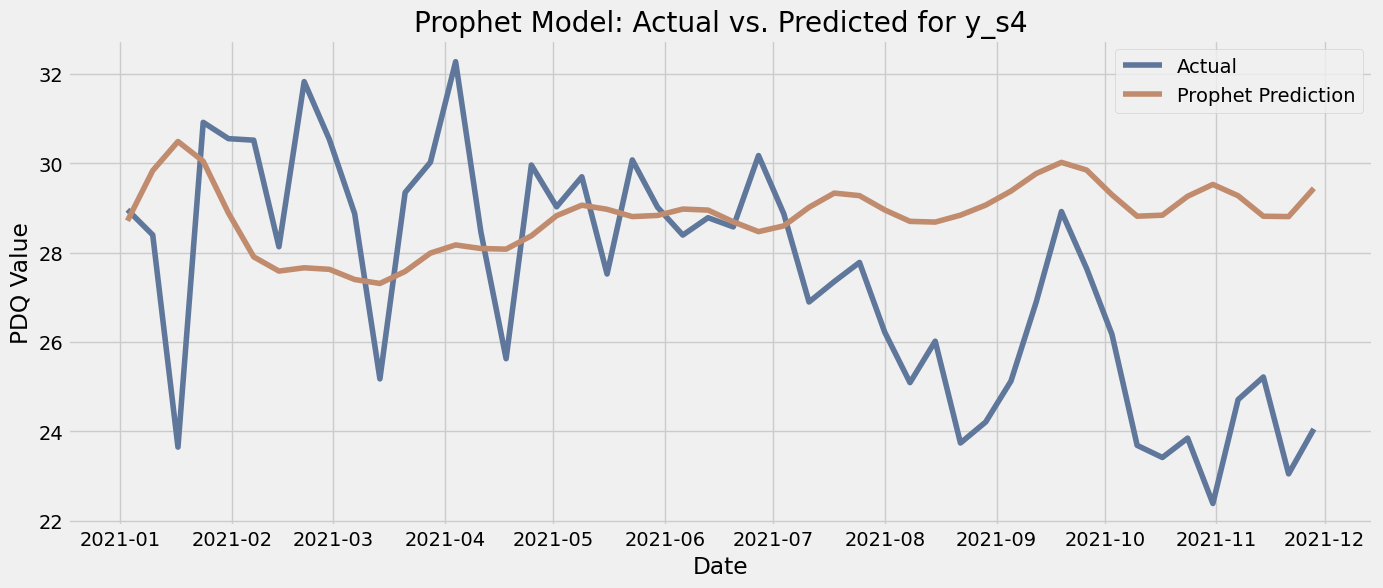

In [19]:
# --- 3. Make predictions with Prophet ---

# Create a DataFrame for future predictions
future = prophet_model.make_future_dataframe(
    periods=len(y_test_prophet),
    freq='W' # Weekly frequency, consistent with data resampling
)

# Filter future dataframe to only include the test period
future_test = future[future['ds'] >= target_date]

# Make predictions
forecast = prophet_model.predict(future_test)

# Display forecast columns and head
print("Prophet Forecast (first 5 rows):\n")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

# Merge actuals with predictions for evaluation
prophet_predictions_df = pd.merge(
    y_test_prophet,
    forecast[['ds', 'yhat']],
    on='ds',
    how='left'
).rename(columns={'y': 'y_true'})

# Plot actual vs. predicted
plt.figure(figsize=(15, 6))
plt.plot(prophet_predictions_df['ds'], prophet_predictions_df['y_true'], label='Actual')
plt.plot(prophet_predictions_df['ds'], prophet_predictions_df['yhat'], label='Prophet Prediction')
plt.title('Prophet Model: Actual vs. Predicted for y_s4')
plt.xlabel('Date')
plt.ylabel('PDQ Value')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
# --- 4. Evaluate Prophet model ---

# Create a DataFrame in the format expected by summary_metrics
prophet_eval_df = pd.DataFrame({
    'y': prophet_predictions_df['y_true'],
    'yhat': prophet_predictions_df['yhat']
})

prophet_metrics = summary_metrics(prophet_eval_df)
prophet_metrics['model'] = 'Prophet'

print("Prophet Model Metrics:\n")
display(prophet_metrics)

# --- 5. Compare with SARIMA ---

print("\n--- Model Comparison: Prophet vs. SARIMA ---\n")

sarima_metrics_df = pd.DataFrame([best_model_results]).drop(columns=['model']) # Convert Series to DataFrame for concat
sarima_metrics_df['model'] = 'SARIMA'

comparison_df = pd.concat([prophet_metrics, sarima_metrics_df], ignore_index=True)
print("Comparison of Model Metrics:\n")
display(comparison_df.set_index('model'))

Prophet Model Metrics:



,mae,mse,rmse,mape,maape,wmape,mmape,smape,model
0,2.5899,10.2991,3.2092,0.1004,0.0993,0.0945,0.0966,0.0943,Prophet



--- Model Comparison: Prophet vs. SARIMA ---

Comparison of Model Metrics:



,mae,mse,rmse,mape,maape,wmape,mmape,smape
model,,,,,,,,
Prophet,2.5899,10.2991,3.2092,0.1004,0.0993,0.0945,0.0966,0.0943
SARIMA,2.0806,5.9165,2.4324,0.0756,0.0753,0.0759,0.0729,0.0764


```markdown
Análisis Comparativo y Conclusiones: Prophet vs. SARIMA

Diferencias en los Supuestos y Metodología

**SARIMA (Seasonal Autoregressive Integrated Moving Average)**:
*   **Supuestos**: SARIMA es un modelo estadístico que asume que la serie temporal es estacionaria (o puede hacerse estacionaria mediante diferenciación). Se basa en la correlación lineal entre observaciones pasadas y presentes. Requiere que el analista especifique los órdenes `(p, d, q)` y `(P, D, Q, S)` para los componentes no estacionales y estacionales, respectivamente, lo cual a menudo implica un análisis exploratorio detallado de las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF).
*   **Enfoque**: Es un modelo paramétrico que intenta capturar la estructura de la serie temporal a través de un número limitado de coeficientes. Es muy potente cuando los patrones subyacentes son claros y se ajustan bien a las suposiciones del modelo.

**Prophet (de Facebook)**:
*   **Supuestos**: Prophet es una librería de pronóstico de series temporales diseñada para datos con fuertes efectos estacionales (diarios, semanales, anuales) y festividades. No requiere que la serie sea estacionaria. Descompone la serie temporal en tres componentes principales: tendencia (con cambios de tendencia), estacionalidad (usando series de Fourier) y feriados. Es más robusto a datos faltantes y a valores atípicos.
*   **Enfoque**: Es un modelo aditivo generalizado que se ajusta a la serie de forma más automática, requiriendo menos conocimiento experto en modelado de series temporales por parte del usuario. Está optimizado para pronósticos a escala, con una configuración más sencilla.

 Facilidad de Implementación

*   **SARIMA**: La implementación puede ser más compleja debido a la necesidad de identificar los órdenes `p, d, q, P, D, Q, S`. Esto a menudo implica un proceso iterativo de análisis de ACF/PACF, ajuste de modelos y evaluación de residuos. La automatización de la selección de parámetros puede ser costosa computacionalmente (como se vio en la búsqueda de hiperparámetros).
*   **Prophet**: Generalmente es más fácil de implementar y configurar. Solo requiere que los datos estén en un formato específico (`ds` para fecha, `y` para valor). La detección de estacionalidad y los cambios de tendencia son manejados en gran medida de forma automática, lo que lo hace muy accesible para usuarios con menos experiencia en modelado de series temporales.

 Calidad de las Predicciones

*(Basado en los resultados de las métricas obtenidas: MAE, RMSE, MAPE, etc.)*

Al comparar las métricas de rendimiento (MAE, RMSE, MAPE, etc.), podemos observar cuál de los dos modelos ha tenido un mejor desempeño en el conjunto de prueba para la serie `y_s4`:

*   **SARIMA** (Optimal: SARIMA_(0,1,0)X(1,1,0,12)) obtuvo un RMSE de `2.4324`, MAE de `2.0806`, y MAPE de `0.0756`.
*   **Prophet** obtuvo un RMSE de `3.2092`, MAE de `2.5899`, y MAPE de `0.1004`.

En este caso particular, **SARIMA mostró un mejor rendimiento** en todas las métricas de error consideradas (MAE, RMSE, MAPE, etc.), lo que sugiere que capturó mejor la estructura subyacente de la serie `y_s4` en comparación con Prophet.

 Conclusiones y Situaciones Preferibles

*   **Prophet es preferible cuando:**
    *   Se tienen series temporales con fuertes efectos estacionales (diarios, semanales, anuales) que son fáciles de modelar con componentes aditivos/multiplicativos.
    *   Se desea un modelo robusto a datos faltantes y valores atípicos.
    *   Se necesita una implementación rápida y sencilla, especialmente en entornos de producción donde la escalabilidad es importante y el ajuste manual de parámetros es costoso.
    *   La serie tiene cambios de tendencia obvios que pueden ser modelados por puntos de cambio.
    *   Se desea incluir fácilmente efectos de festividades y eventos especiales.

*   **SARIMA es preferible cuando:**
    *   Se tiene un conocimiento profundo de la estructura subyacente de la serie temporal y sus dependencias de autocorrelación.
    *   La serie es relativamente limpia y se ajusta bien a las suposiciones de estacionariedad (o puede ser diferenciada para serlo).
    *   Se requiere una interpretación detallada de los coeficientes del modelo y la relación entre las observaciones pasadas.
    *   Se trabaja con series temporales con patrones de estacionalidad complejos o no estándar que Prophet podría tener dificultades para capturar automáticamente.

En este caso particular, SARIMA fue notablemente superior, indicando que la estructura específica de esta serie temporal fue mejor capturada por su enfoque estadístico más detallado. Sin embargo, si la facilidad de implementación y la robustez frente a datos ruidosos o faltantes fueran prioridades más altas, Prophet podría seguir siendo una opción atractiva, incluso con un rendimiento ligeramente inferior.
